In this notebook, we get an estimate of % forest cover from nadir in the vicnity of Ameriflux sites. Instead of the coarse ALOS/PALSAR mosaics, we derive this from NAIP.

In [1]:
import odc.stac
import odc.geo.geobox
import odc.geo.xr
import planetary_computer as pc
import pystac_client
import pystac
import pyproj
import stackstac
import rasterio
import rioxarray

import numpy as np
from matplotlib import pyplot as plt
from skimage.filters import threshold_otsu

# Load the PC catalog
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,
)

In [2]:
lon, lat = -121.1403, 43.6479
buffer = 0.01

bbox = [lon - buffer, lat - buffer, lon + buffer, lat + buffer] # small square
date = "2020-01-01" # doesn't really matter

In [3]:
naip = catalog.search(
    collections=["naip"],
    bbox=bbox
).get_all_items()

# We are only searching for MODIS to align the grid
modis = catalog.search(
    collections=["modis-11A2-061"],
    bbox=bbox,
    datetime=date
).get_all_items()

# isolate the most recent image
most_recent_naip = max(naip, key=lambda x: x.datetime)
most_recent_naip

id: or_m_4312123_se_10_060_20200625
"bbox: [-121.191926, 43.622153, -121.120486, 43.690336]"
gsd: 0.6
datetime: 2020-06-25T00:00:00Z
naip:year: 2020
"proj:bbox: [645876.0, 4831620.0, 651474.0, 4839072.0]"
proj:epsg: 26910
naip:state: or
"proj:shape: [12420, 9330]"
"proj:transform: [0.6, 0.0, 645876.0, 0.0, -0.6, 4839072.0, 0.0, 0.0, 1.0]"
https://stac-extensions.github.io/eo/v1.0.0/schema.json


In [4]:
naip_rio = rioxarray.open_rasterio(most_recent_naip.assets["image"].href,
                                   band_as_variable=True)

modis_data = odc.stac.load(
    modis,
    bbox=bbox,
    bands=["LST_Day_1km"]
).squeeze().drop_vars("time")

In [5]:
# Set up coordinate transformations
naip_prj  = pyproj.CRS(naip_rio.rio.crs)
modis_prj = '+proj=sinu +R=6371007.181 +nadgrids=@null +wktext'

latlon_to_modis_tform = pyproj.Transformer.from_crs("EPSG:4326", modis_prj, always_xy=True)
latlon_to_naip_tform  = pyproj.Transformer.from_crs("EPSG:4326", naip_prj, always_xy=True)
modis_to_naip_tform   = pyproj.Transformer.from_crs(modis_prj, naip_prj, always_xy=True)

In [6]:
modis_data

<xarray.Dataset>
Dimensions:      (y: 3, x: 6)
Coordinates:
  * y            (y) float64 4.854e+06 4.853e+06 4.852e+06
  * x            (x) float64 -9.749e+06 -9.749e+06 ... -9.746e+06 -9.745e+06
    spatial_ref  int32 0
Data variables:
    LST_Day_1km  (y, x) uint16 13312 13287 13284 13284 ... 13552 13541 13520

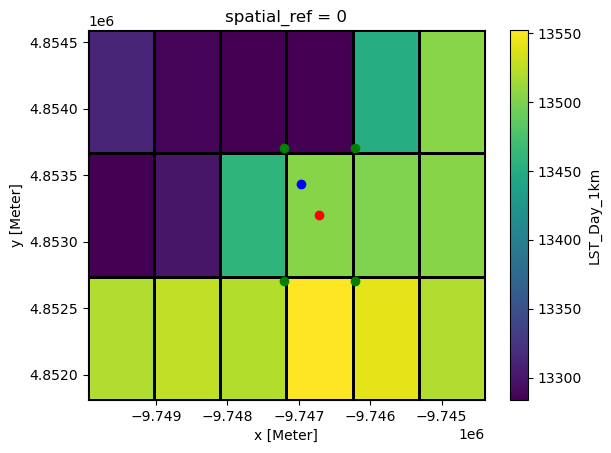

In [7]:
# Get nearest MODIS pixel bounds to the latlon of interest
mod_x, mod_y = latlon_to_modis_tform.transform(lon, lat)

closest_x = modis_data.x.values[np.argmin(np.abs(mod_x - modis_data.x.values))]
closest_y = modis_data.y.values[np.argmin(np.abs(mod_y - modis_data.y.values))]

closest_px_bounds_x = [closest_x - 500, closest_x - 500, closest_x + 500, closest_x + 500]
closest_px_bounds_y = [closest_y - 500, closest_y + 500, closest_y - 500, closest_y + 500]

modis_data["LST_Day_1km"].plot.pcolormesh(edgecolors="k", linewidth=1)

plt.scatter([mod_x], [mod_y], color="blue")
plt.scatter([closest_x], [closest_y], color="red")
plt.scatter(closest_px_bounds_x, closest_px_bounds_y, color="green")

In [8]:
(naip_bounds_x, naip_bounds_y) = modis_to_naip_tform.transform(
    closest_px_bounds_x, closest_px_bounds_y
)

In [9]:
naip_min_x, naip_max_x = np.min(naip_bounds_x), np.max(naip_bounds_x)
naip_min_y, naip_max_y = np.min(naip_bounds_y), np.max(naip_bounds_y)

buffer = 0 # for easier visualization

# For visualization, clip down to within 100m of the pixel bounds. This is really slow,
# is there a way to clip just on the coordinate indices?
naip_clip = naip_rio.sel(
    x=slice(naip_min_x-buffer, naip_max_x+buffer),
    # NAIP is indexed decreasing on the y coordinate, so these have to be flipped
    y=slice(naip_max_y+buffer, naip_min_y-buffer)
)

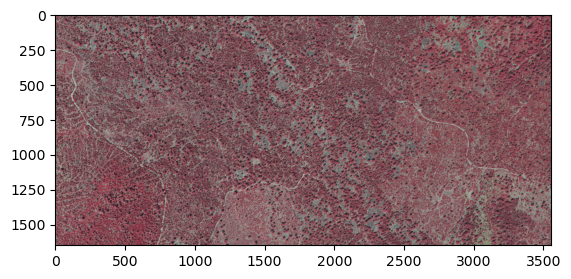

In [10]:
# Verify that the bands are right
plt.imshow(np.stack(
    (naip_clip.band_4.values,
    naip_clip.band_1.values,
    naip_clip.band_2.values),
    axis=-1
))

In [11]:
# NDVI calculations will break on these datatypes because they are unsigned integers. Need
# to convert to signed ints to allow negative values.
naip_clip = naip_clip.astype(np.int16)

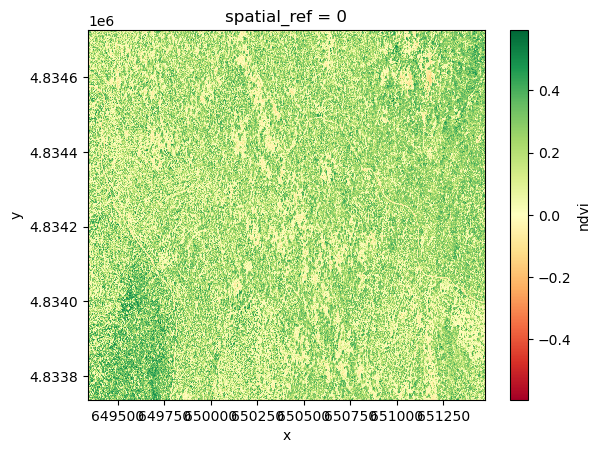

In [12]:
naip_clip["ndvi"] = (naip_clip.band_4 - naip_clip.band_1) / (naip_clip.band_4 + naip_clip.band_1)
naip_clip.ndvi.plot.imshow(cmap="RdYlGn")

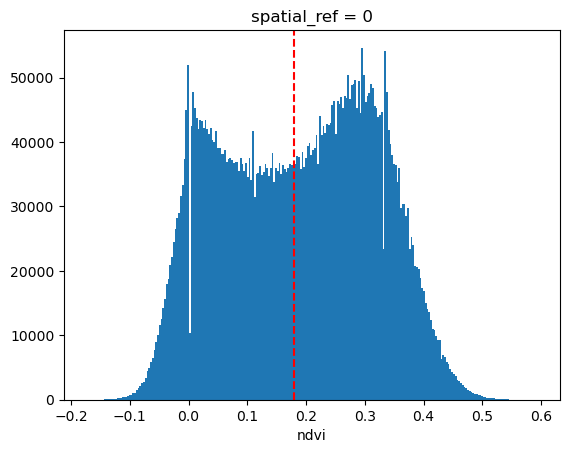

In [13]:
threshold = threshold_otsu(naip_clip.ndvi.values)
naip_clip["ndvi_forest"] = naip_clip.ndvi > threshold

naip_clip.ndvi.plot.hist(bins=256)
plt.axvline(threshold, color="red", linestyle="--")
plt.show()

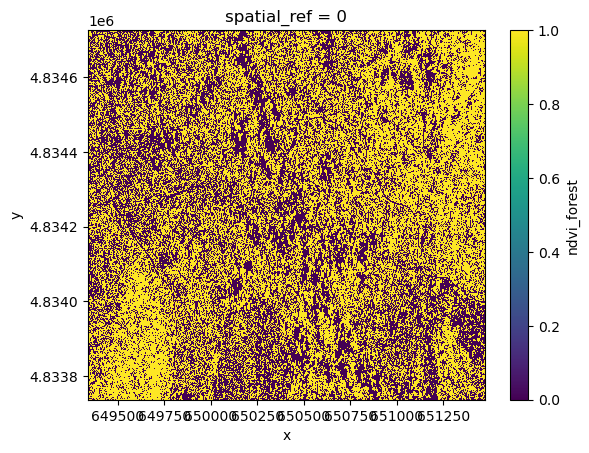

In [14]:
naip_clip.ndvi_forest.plot.imshow()

In [15]:
print("Proportion forest cover: {:.2f}%".format(naip_clip.ndvi_forest.mean() * 100))

Proportion forest cover: 53.14%


## Compute for all Ameriflux sites

In [71]:
# Make the above more compact
def load_naip(lat, lon):
    naip_search_distance = 1e-6
    naip_bbox = [lon - naip_search_distance , lat - naip_search_distance, 
                 lon + naip_search_distance , lat + naip_search_distance] # a point
    
    naip_search = catalog.search(
        collections=["naip"],
        bbox=naip_bbox
    ).get_all_items()
    # isolate the most recent image
    most_recent_naip = max(naip_search, key=lambda x: x.datetime)
    
    return rioxarray.open_rasterio(most_recent_naip.assets["image"].href,
                                   band_as_variable=True)
    

def classify_naip_ndvi_otsu(naip):
    # Calculates and classifies NDVI values in a NAIP dataset using
    # Otsu's threshold method, modifying the dataset in place.
    naip["ndvi"] = (naip.band_4 - naip.band_1) / (naip.band_4 + naip.band_1)
    
    # Threshold
    threshold = threshold_otsu(naip.ndvi.values)
    naip["ndvi_forest"] = naip.ndvi > threshold
    
def classify_naip_ndvi_threshold(naip, threshold=0.2):
    # Calculates and classifies NDVI values on a manual threshold
    naip["ndvi"] = (naip.band_4 - naip.band_1) / (naip.band_4 + naip.band_1)
    naip["ndvi_forest"] = naip.ndvi > threshold
    
def get_naip_clip_coordinates(naip, lon, lat, buffer=500):
    # Set up projection transformers. The NAIP image may have a different
    # projection in different parts of the world.
    naip_prj  = pyproj.CRS(naip.rio.crs)
    
    latlon_to_naip_tform = pyproj.Transformer.from_crs("EPSG:4326", naip_prj, always_xy=True)
    
    naip_x, naip_y = latlon_to_naip_tform.transform(lon, lat)
    return naip_x - buffer, naip_x + buffer, naip_y - buffer, naip_y + buffer
    
def get_forest_cover(lon, lat, buffer=500, date="2020-01-01", 
                     classifier="otsu", threshold=0.2, debug=False):
    # Load the data
    if debug: print("Loading data...")
    naip = load_naip(lat, lon)
    #return load_modis_naip(lat, lon)
    
    # Get clipping coordinates to align with MODIS pixel
    if debug: print("Getting clip coordinates...")
    naip_min_x, naip_max_x, naip_min_y, naip_max_y = get_naip_clip_coordinates(
        naip, lon, lat, buffer=buffer
    )
    
    # Clip NAIP to the sampling area. This clips on indexed coordinates so
    # it is very fast. Also convert so signed integers to handle negatives
    # in the NDVI calculation.
    if debug: print("Clipping NAIP...")
    naip_clip = naip.sel(
        x=slice(naip_min_x, naip_max_x),
        # NAIP is indexed decreasing on the y coordinate, so these have to be flipped
        y=slice(naip_max_y, naip_min_y)
    ).astype(np.int16)
    
    if debug:
        plt.imshow(np.stack(
            (naip_clip.band_1.values,
            naip_clip.band_2.values,
            naip_clip.band_3.values),
            axis=-1
        ))
        plt.show()
    
    if debug: print("Classifying forest by NDVI...")
    # Classify forest by NDVI
    if classifier == "otsu":
        classify_naip_ndvi_otsu(naip_clip)
    elif classifier == "threshold":
        classify_naip_ndvi_threshold(naip_clip, threshold=threshold)
    
    if debug: 
        naip_clip.ndvi.plot.imshow()
        plt.show()
    
    # Return pct forest cover
    return np.mean(naip_clip.ndvi_forest.values)

Loading data...
Getting clip coordinates...
Clipping NAIP...


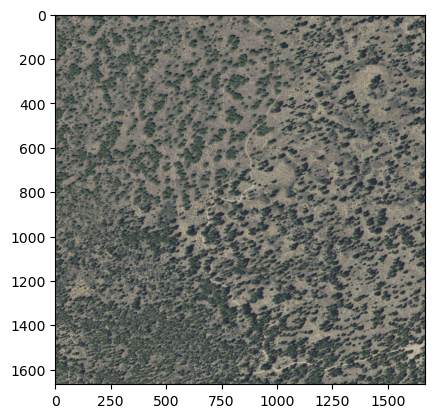

Classifying forest by NDVI...


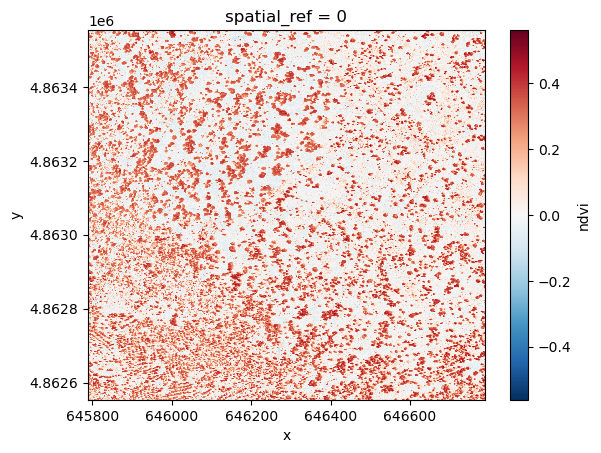

0.3668824458397636

In [83]:
lon, lat = -121.17824440982083, 43.9060697775721
get_forest_cover(lon, lat, classifier="threshold", threshold=0.1, debug=True)

In [95]:
import pandas as pd
sites = pd.read_csv("ameriflux_canopy_temp_site_locs.csv")

def driver(site, lon, lat):
    try:
        return get_forest_cover(
            lon, lat, classifier="threshold", threshold=0.1
        )
    except Exception as e:
        print("Site {} failed:".format(site), e)
        return np.nan

sites["forest_cover_naip"] = sites.apply(
    lambda row: driver(row["SITE_ID"], row["LOCATION_LONG"], row["LOCATION_LAT"]),
    axis=1
)

Site CR-SoC failed: max() arg is an empty sequence
Site PR-xGU failed: max() arg is an empty sequence
Site PR-xLA failed: max() arg is an empty sequence
Site US-xBA failed: max() arg is an empty sequence
Site US-xBN failed: max() arg is an empty sequence
Site US-xDJ failed: max() arg is an empty sequence
Site US-xHE failed: max() arg is an empty sequence
Site US-xPU failed: max() arg is an empty sequence
Site US-xTL failed: max() arg is an empty sequence


In [96]:
# Join the PALSAR forest data
sites["forest_cover_palsar"] = pd.read_csv("ameriflux_site_forest_cover.csv")["forest_cover"]

In [97]:
sites.to_csv("ameriflux_combined_forest_cover.csv")